# Variational Time-Frequency Mode Tracking Decomposition (VTFMTD)

**VTFMTD** (Dong et al., 2026) performs **mode separation on the STFT plane** and jointly tracks **instantaneous frequency (IF)** ridges. It is aimed at micro-Doppler / non-stationary radar signatures, where classical 1-D decompositions (e.g. VMD) separate modes but do not directly expose time-varying IFs.

> Dong, H., Shan, T., Yu, G., Shi, Y., Chen, Y.  
> *Variational time-frequency mode tracking for micro-Doppler signature extraction.*  
> Signal Processing, 246:110603, 2026.  
> https://doi.org/10.1016/j.sigpro.2026.110603

This notebook:
1. summarises the algorithm principles from the paper;
2. reproduces the MATLAB demos `test1.m` / `test2.m` with `pysdkit.VTFMTD`.

## 1. Imports

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if not (ROOT / "pysdkit").is_dir():
    for parent in ROOT.parents:
        if (parent / "pysdkit").is_dir():
            ROOT = parent
            break
if str(ROOT) not in sys.path and (ROOT / "pysdkit").is_dir():
    sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import detrend
from matplotlib.colors import ListedColormap

from pysdkit import VTFMTD
from pysdkit._tfa import (
    stft,
    frequency_axis,
    moving_average_if,
    load_dual_signal_noise,
    load_single_nsignal,
    load_map2,
)

plt.rcParams["figure.dpi"] = 120
print(VTFMTD())

Variational Time-Frequency Mode Tracking Decomposition (VTFMTD)


## 2. Algorithm principles

### 2.1 From 1-D signal to STFT modes

Given a (possibly complex) signal $s(t)$, compute its STFT $W(t,\eta)$.
VTFMTD seeks mode STFTs $\{W_k\}$ and IF trajectories $\{\hat\eta_k(t)\}$ by solving a constrained variational problem in the **time–frequency plane**:

$$
\min_{\{W_k\},\{\hat\eta_k\}}
\sum_{k=1}^{K}
\big\| (\eta - \hat\eta_k(t))\, W_k(t,\eta) \big\|_2^2
\quad\text{s.t.}\quad
\sum_{k=1}^{K} W_k(t,\eta) = W(t,\eta).
$$

Minimising the spectral second-order central moment concentrates each mode around its IF ridge (narrow instantaneous bandwidth), while the equality constraint preserves the composite STFT.

### 2.2 Relation to VMD (and why it is not a VMD variant)

Classic VMD jointly estimates modes in the **1-D Fourier domain** around **constant** centre frequencies.
VTFMTD borrows the *variational + ADMM / Wiener-filter* idea, but:

- works on the **STFT** $W(t,\eta)$ (2-D TF coefficients);
- tracks **time-varying** IFs $\hat\eta_k(t)$;
- returns mode STFTs $+~$ IF trajectories (micro-Doppler features), not classical IMF time series.

### 2.3 ADMM updates (MATLAB / paper)

1. **TF Wiener update** of each mode STFT (bandwidth controlled by $\alpha$);
2. **Centroid IF** from the energy centre of gravity along frequency;
3. **IF smoothing** via a first-difference regulariser (parameter $\beta$);
4. **Dual ascent** on the reconstruction residual (step $\sigma$).

In PySDKit this is `pysdkit.VTFMTD` / `pysdkit._tfa.vtfmtd`.

## 3. Demo A — dual FM components (`test1.m`)

Synthetic two-component complex chirps (noiseless), then the packaged noisy recording `Dual_signal_noise`.

In [2]:
fs = 3000.0
t = np.arange(1, int(fs) + 1) / fs
f_axis = frequency_axis(t.size, fs)

sig1 = np.exp(1j * 2 * np.pi * (250 * t + 0.5 / np.pi * np.sin(2 * np.pi * 20 * t)))
sig1 = sig1 + np.exp(
    1j * 2 * np.pi * (950 * t + 0.5 / np.pi * np.sin(2 * np.pi * 60 * t))
)
IF_low = 250 + 20 * np.cos(40 * np.pi * t)
IF_high = 950 + 60 * np.cos(120 * np.pi * t)

model = VTFMTD(
    hlength=30,
    K=2,
    alpha=1e-5,
    sigma=0.01,
    beta=1.0,
    max_iter=100,
    epsilon=1e-3,
)
Gk, omega = model.fit_transform(sig1, omega_init=np.array([250.0, 950.0]))
print("Gk shape (F, T, K) =", Gk.shape)

Gk shape (F, T, K) = (1500, 3000, 2)


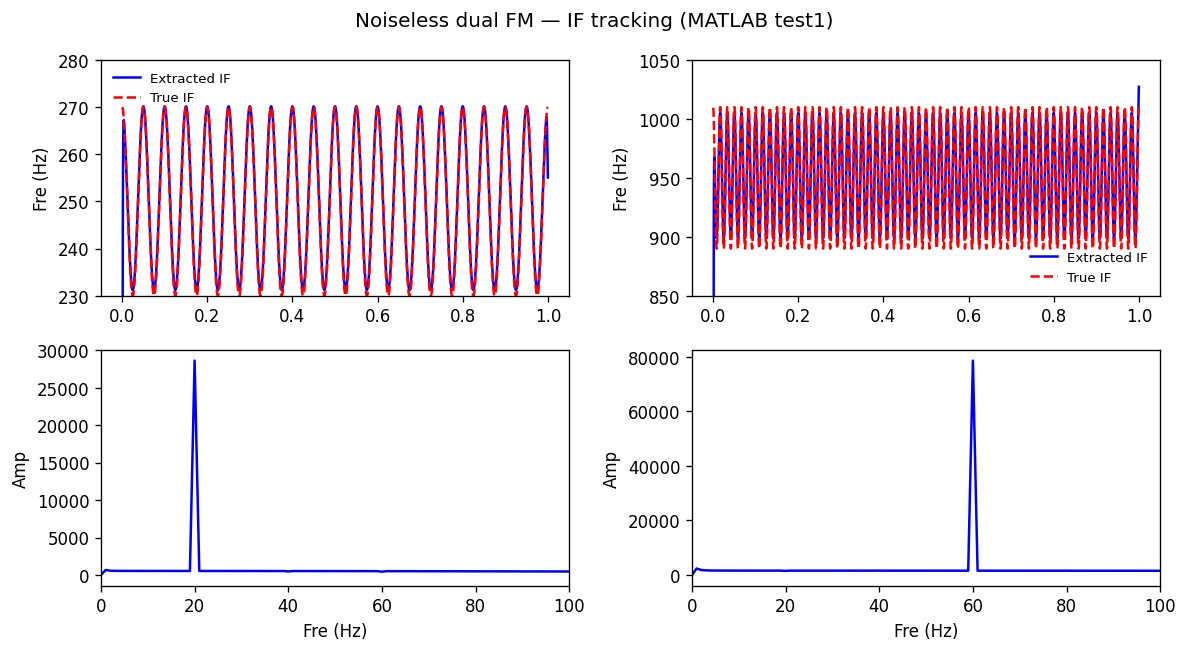

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(10, 5.5))

axes[0, 0].plot(t, omega[0, :, 0], "b", label="Extracted IF")
axes[0, 0].plot(t, IF_low, "r--", label="True IF")
axes[0, 0].set_ylabel("Fre (Hz)")
axes[0, 0].set_ylim(230, 280)
axes[0, 0].legend(fontsize=8, frameon=False)

axes[0, 1].plot(t, omega[0, :, 1], "b", label="Extracted IF")
axes[0, 1].plot(t, IF_high, "r--", label="True IF")
axes[0, 1].set_ylabel("Fre (Hz)")
axes[0, 1].set_ylim(850, 1050)
axes[0, 1].legend(fontsize=8, frameon=False)

ft1 = np.abs(np.fft.fft(detrend(omega[0, :, 0])))
ft2 = np.abs(np.fft.fft(detrend(omega[0, :, 1])))
axes[1, 0].plot(f_axis, ft1[: f_axis.size], "b")
axes[1, 0].set_xlim(0, 100)
axes[1, 0].set_xlabel("Fre (Hz)")
axes[1, 0].set_ylabel("Amp")

axes[1, 1].plot(f_axis, ft2[: f_axis.size], "b")
axes[1, 1].set_xlim(0, 100)
axes[1, 1].set_xlabel("Fre (Hz)")
axes[1, 1].set_ylabel("Amp")

fig.suptitle("Noiseless dual FM — IF tracking (MATLAB test1)")
plt.tight_layout()
plt.show()

### 3.1 Packaged noisy dual signal

`load_dual_signal_noise()` ships the MATLAB `Dual_signal_noise.mat` array with the wheel.

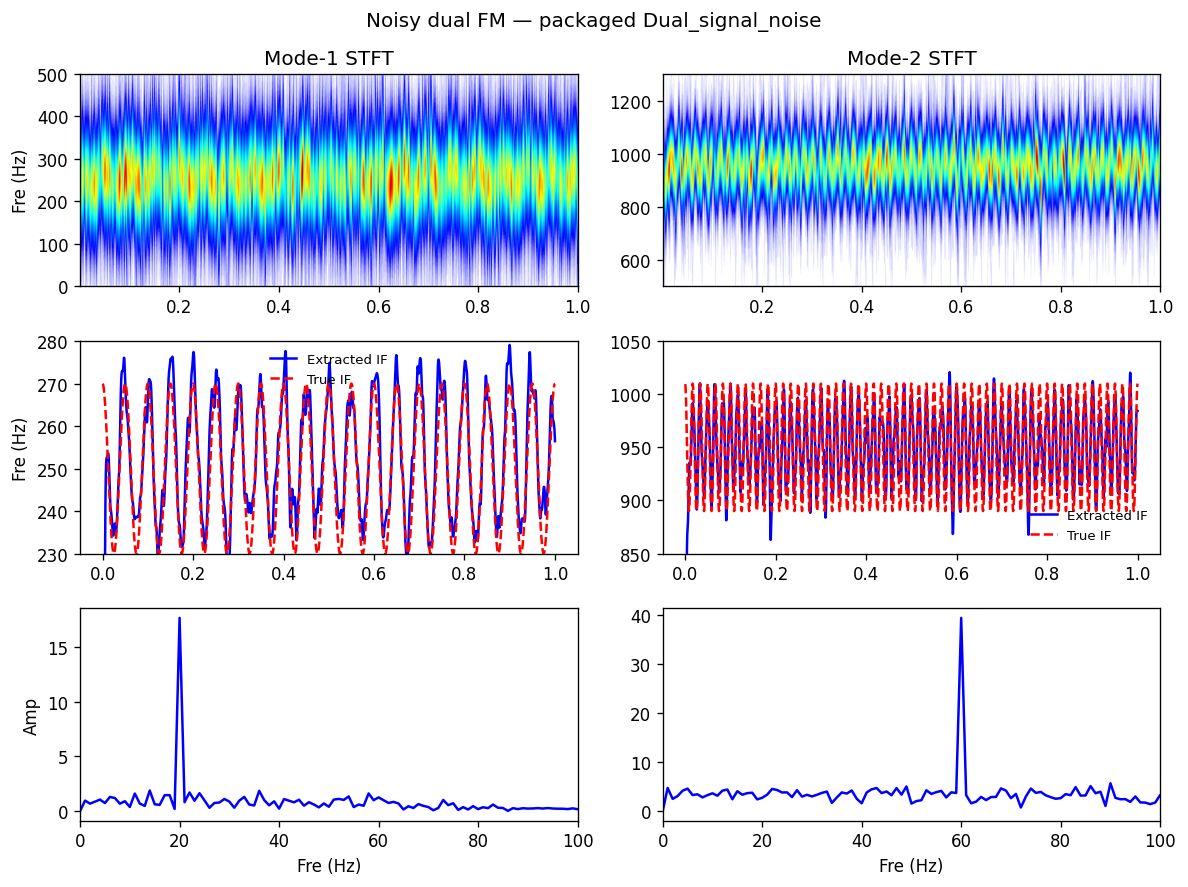

In [4]:
demo = load_dual_signal_noise()
sig_n = demo["signal"]
t = demo["t"]
fs = demo["fs"]
f_axis = frequency_axis(sig_n.size, fs)
cmap = ListedColormap(load_map2())

model_n = VTFMTD(
    hlength=28,
    K=2,
    alpha=5e-5,
    sigma=0.01,
    beta=0.3,
    max_iter=100,
    epsilon=1e-3,
)
Gk_n, omega_n = model_n.fit_transform(sig_n, omega_init=np.array([250.0, 950.0]))

FIF_low = moving_average_if(omega_n[0, :, 0], win=30)

fig, axes = plt.subplots(3, 2, figsize=(10, 7.5))
axes[0, 0].imshow(
    np.abs(Gk_n[:, :, 0]),
    aspect="auto",
    origin="lower",
    extent=[t[0], t[-1], f_axis[0], f_axis[-1]],
    cmap=cmap,
)
axes[0, 0].set_ylim(0, 500)
axes[0, 0].set_ylabel("Fre (Hz)")
axes[0, 0].set_title("Mode-1 STFT")

axes[0, 1].imshow(
    np.abs(Gk_n[:, :, 1]),
    aspect="auto",
    origin="lower",
    extent=[t[0], t[-1], f_axis[0], f_axis[-1]],
    cmap=cmap,
)
axes[0, 1].set_ylim(500, 1300)
axes[0, 1].set_title("Mode-2 STFT")

axes[1, 0].plot(t, FIF_low, "b", label="Extracted IF")
axes[1, 0].plot(t, IF_low, "r--", label="True IF")
axes[1, 0].set_ylim(230, 280)
axes[1, 0].set_ylabel("Fre (Hz)")
axes[1, 0].legend(fontsize=8, frameon=False)

axes[1, 1].plot(t, omega_n[0, :, 1], "b", label="Extracted IF")
axes[1, 1].plot(t, IF_high, "r--", label="True IF")
axes[1, 1].set_ylim(850, 1050)
axes[1, 1].legend(fontsize=8, frameon=False)

N = sig_n.size
ft1 = np.abs(np.fft.fft(detrend(FIF_low))) / N * 2
ft2 = np.abs(np.fft.fft(detrend(omega_n[0, :, 1]))) / N * 2
axes[2, 0].plot(f_axis, ft1[: f_axis.size], "b")
axes[2, 0].set_xlim(0, 100)
axes[2, 0].set_xlabel("Fre (Hz)")
axes[2, 0].set_ylabel("Amp")

axes[2, 1].plot(f_axis, ft2[: f_axis.size], "b")
axes[2, 1].set_xlim(0, 100)
axes[2, 1].set_xlabel("Fre (Hz)")

fig.suptitle("Noisy dual FM — packaged Dual_signal_noise")
plt.tight_layout()
plt.show()

## 4. Demo B — micro-Doppler blade model (`test2.m`)

Noiseless analytic MDS model, then packaged `Single_nsignal`.

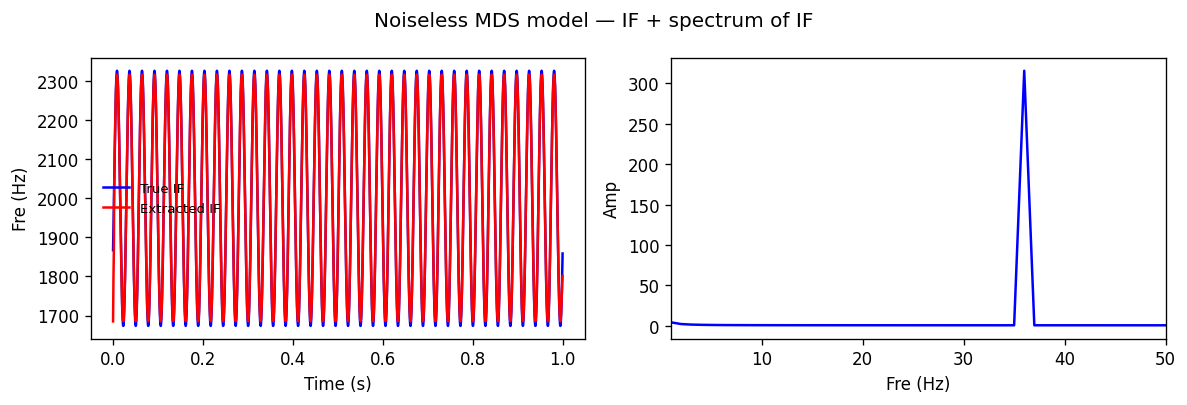

In [5]:
lam = 0.3
L = 0.5
beta_ang = np.pi / 6
phi0 = np.pi / 5
wr = 2 * np.pi * 36
alpha_ang = np.pi / 3
Fs = 8011.0
t = np.linspace(0.0, 1.0, int(Fs), endpoint=False)
N = t.size
f_axis = frequency_axis(N, Fs)

arg = phi0 + wr * t - alpha_ang
cos_term = np.cos(beta_ang) * np.cos(arg)
u = (2 * np.pi / lam) * L * cos_term
signal_envelop = np.sinc(u / np.pi)
signal_phase = np.exp(-1j * 4 * np.pi / lam * (cos_term / 2 * L))
IF_md = wr * L / lam * np.cos(beta_ang) * np.sin(phi0 + wr * t - alpha_ang)
signal = signal_envelop * signal_phase
signal1 = signal * np.exp(1j * 2 * np.pi * 2000 * t)

model_md = VTFMTD(
    hlength=21,
    K=1,
    alpha=1e-8,
    sigma=0.01,
    beta=0.3,
    max_iter=100,
    epsilon=1e-3,
)
Gk_md, omega_md = model_md.fit_transform(signal1, omega_init=np.array([2000.0]))
FIF = moving_average_if(omega_md[0, :, 0], win=30)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
axes[0].plot(t, IF_md + 2000, "b", label="True IF")
axes[0].plot(t, FIF, "r", label="Extracted IF")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Fre (Hz)")
axes[0].legend(fontsize=8, frameon=False)

ft1 = np.abs(np.fft.fft(detrend(FIF))) / N * 2
axes[1].plot(f_axis[:4006], ft1[:4006], "b")
axes[1].set_xlim(1, 50)
axes[1].set_xlabel("Fre (Hz)")
axes[1].set_ylabel("Amp")
fig.suptitle("Noiseless MDS model — IF + spectrum of IF")
plt.tight_layout()
plt.show()

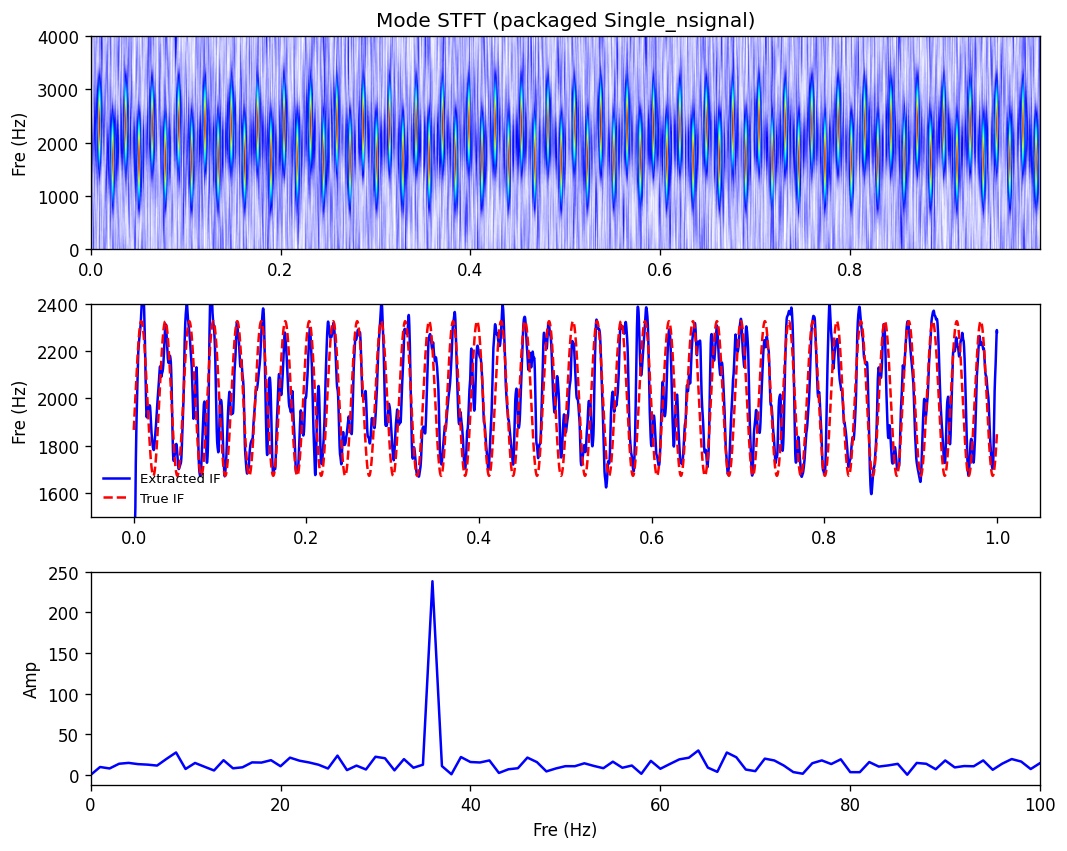

In [6]:
demo_s = load_single_nsignal()
sig_s = demo_s["signal"]
t_s = demo_s["t"]
fs_s = demo_s["fs"]
f_s = frequency_axis(sig_s.size, fs_s)
cmap = ListedColormap(load_map2())

model_sn = VTFMTD(
    hlength=25,
    K=1,
    alpha=1e-8,
    sigma=0.01,
    beta=0.1,
    max_iter=100,
    epsilon=1e-3,
)
Gk_s, omega_s = model_sn.fit_transform(sig_s, omega_init=np.array([2000.0]))
FIF_s = moving_average_if(omega_s[0, :, 0], win=30)

# true IF from the same geometric model (carrier 2000 Hz)
IF_true = IF_md + 2000

fig, axes = plt.subplots(3, 1, figsize=(9, 7.2), sharex=False)
axes[0].imshow(
    np.abs(Gk_s[:, :, 0]),
    aspect="auto",
    origin="lower",
    extent=[t_s[0], t_s[-1], f_s[0], f_s[-1]],
    cmap=cmap,
)
axes[0].set_ylabel("Fre (Hz)")
axes[0].set_title("Mode STFT (packaged Single_nsignal)")

axes[1].plot(t_s, FIF_s, "b", label="Extracted IF")
axes[1].plot(t_s, IF_true, "r--", label="True IF")
axes[1].set_ylim(1500, 2400)
axes[1].set_ylabel("Fre (Hz)")
axes[1].legend(fontsize=8, frameon=False)

ft = np.abs(np.fft.fft(detrend(FIF_s))) / sig_s.size * 2
axes[2].plot(f_s, ft[: f_s.size], "b")
axes[2].set_xlim(0, 100)
axes[2].set_xlabel("Fre (Hz)")
axes[2].set_ylabel("Amp")
plt.tight_layout()
plt.show()

## 5. Takeaways

- VTFMTD decomposes **STFT coefficients**, not a Cohen-class quadratic TFD; the input is still a 1-D (often complex) signal.
- Primary products are **mode STFTs** and **IF trajectories** for micro-Doppler analysis.
- Use `store`-style initialisation of IF centres (bin / Hz units as in the MATLAB demos when $f_s \approx N$).
- Packaged demos: `load_dual_signal_noise()`, `load_single_nsignal()`, `load_map2()`.